# Notebook - Análise do Heapsort
## 1. Importação das bibliotecas
Bibliotecas numpy e pandas importadas para trabalhar com dados, matplot para trabalhar com gráficos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

## 2. Carregar os Dados
Carregar heap.csv para analisar dados do heapsort

In [3]:
heap = pd.read_csv("../results/heap.csv")
heap.head()

,vector_type,algorithm,size,time_ms,stress,carga,ram_kb_max,ram_kb_media,energy_j,comparisons,swaps
0,endnoise,HeapSort,10000000,703.818,none,0.0,43112,42886,12.8442,446056168,232185536
1,ordered,HeapSort,10000000,617.532,none,0.0,43128,42934,14.3763,445162673,231881708
2,random,HeapSort,10000000,1481.630,none,0.0,43088,42895,36.4218,434646478,223836727
3,random_swaps,HeapSort,10000000,661.892,none,0.0,43080,42886,15.6403,444849277,231605792
4,repeated_1_5,HeapSort,10000000,590.864,none,0.0,43120,42926,11.6292,351622539,177537528


## 3. Estatísticas Descritivas
Por combinação de mesmo vetor e estresse, obter média dos dados e standard deviation do tempo.

In [4]:
summary = (
    heap
    .groupby(["vector_type","stress","carga"])
    .agg(
        tempo_medio=("time_ms","mean"),
        desvio=("time_ms","std"),
        memoria_pico=("ram_kb_max","mean"),
        memoria_media=("ram_kb_media","mean"),
        energia=("energy_j","mean"),
        comparacoes=("comparisons","mean"),
        swaps=("swaps","mean")
    )
)

summary

tempo_medio      desvio  memoria_pico  \
vector_type  stress carga                                          
endnoise     both   0.5      855.38200   73.571444    16819996.8   
                    1.0     1706.07400  353.193403    31055867.2   
             cpu    0.5      867.31760   71.172705       43239.2   
                    1.0     1206.66000  163.746342       43251.2   
             none   0.0      674.42860   29.959647       43124.8   
             ram    0.5      674.90780   47.106298    16819846.4   
                    1.0      969.69940   93.018892    30924418.4   
ordered      both   0.5      845.24820   69.405384    16820024.0   
                    1.0     1520.25000  138.265443    31079663.2   
             cpu    0.5      793.56000   38.947366       43232.0   
                    1.0     1079.17980  180.552252       43292.0   
             none   0.0      650.86860   27.934007       43100.0   
             ram    0.5      643.44240   26.605930    16819956.0   
                    1.0      899.00440   75.867838    31061504.0   
random       both   0.5     2304.66200  165.966753    16820065.6   
                    1.0     4008.66800  699.332785    31092208.8   
             cpu    0.5     1957.76800  181.518146       43248.8   
                    1.0     2581.21000  289.347663       43274.4   
             none   0.0     1540.17200   72.833443       43112.0   
             ram    0.5     1848.35000   84.686032    16819869.6   
                    1.0     2381.44800  321.228812    31097709.6   
random_swaps both   0.5      976.68940   60.871956    16820060.8   
                    1.0     1691.97600  253.896673    31088394.4   
             cpu    0.5      910.22940   73.950391       43248.8   
                    1.0     1273.16760  186.635393       43276.8   
             none   0.0      676.92260   31.688936       43096.0   
             ram    0.5      734.36720   53.305798    16819889.6   
                    1.0     1003.68660  145.500879    31099500.0   
repeated     both   0.5       55.96508    0.596275    16819953.6   
                    1.0      240.24780   21.511144    31125042.4   
             cpu    0.5       51.90650    2.911004       43236.8   
                    1.0       87.52536   15.490829       43291.2   
             none   0.0       32.24004    0.488892       43089.6   
             ram    0.5       35.79210    3.068710    16819865.6   
                    1.0      134.44940   17.495217    31098369.6   
repeated_1_5 both   0.5      762.23200   47.541047    16819952.8   
                    1.0     1487.21400  160.052230    31121834.4   
             cpu    0.5      688.96680   32.656933       43252.8   
                    1.0     1070.96200   48.603220       43278.4   
             none   0.0      572.60260   24.836824       43116.8   
             ram    0.5      576.59040   20.659657    16819903.2   
                    1.0      765.09900   37.351452    31100939.2   
reversed     both   0.5      878.57620   55.995211    16820002.4   
                    1.0     1733.62800  255.745799    31128493.6   
             cpu    0.5      856.87440   65.404973       43249.6   
                    1.0     1204.69200  145.438709       43279.2   
             none   0.0      698.02880   32.602139       43107.2   
             ram    0.5      709.26760   49.480435    16819928.0   
                    1.0      982.46260   63.357769    31129747.2   
zigzag       both   0.5      951.86980   73.109987    16819952.0   
                    1.0     1583.40200  319.180586    31084338.4   
             cpu    0.5      902.09740   45.281576       43251.2   
                    1.0     1227.13800  139.124003       43279.2   
             none   0.0      722.99080   28.695605       43120.8   
             ram    0.5      774.91820   35.608402    16819936.8   
                    1.0     1082.23840  107.206047    31091446.4   

                           memoria_media     energia  comparacoes        swaps  
v

### Análise dados estatícos:
O tempo de execução aumenta de forma sistemática conforme cresce a intensidade do estresse. Em praticamente todos os tipos de vetor, a execução sem estresse (none) apresentou os menores tempos, seguida pelo estresse apenas de RAM, depois pelo estresse de CPU e, por fim, pelo cenário combinado (both) com carga 1,0.

Esse comportamento evidencia que o HeapSort é mais sensível à contenção dos recursos computacionais quando múltiplos subsistemas são pressionados simultaneamente.
O vetor random apresentou o maior impacto do estresse. O tempo aumentou de aproximadamente 1,54 s para 4,01 s, um crescimento superior a 160%.

Já o vetor repeated permaneceu sendo o mais rápido em todos os cenários, consequência da grande quantidade de chaves repetidas, que reduz significativamente o número de trocas realizadas pelo HeapSort.

---
O desvio padrão também cresce conforme aumenta o nível de carga.

Sem estresse, normalmente fica entre 25 ms e 35 ms para a maioria dos vetores. Sob estresse combinado de carga 1,0, diversos casos ultrapassam 200 ms, chegando a aproximadamente 700 ms para o vetor aleatório.

Isso indica que a competição pelos recursos do sistema aumenta também a variabilidade das medições.

---
Como esperado, o número de comparações e trocas permanece exatamente constante para um mesmo conjunto de dados.

---
Os resultados também evidenciam que o HeapSort apresenta comportamento relativamente estável em relação à ordem inicial dos elementos.

Os vetores ordered, reversed, zigzag, random_swaps e endnoise produziram tempos relativamente próximos entre si, enquanto os vetores random demandaram significativamente mais tempo devido ao maior número de reorganizações do heap. Já os vetores repeated destacaram-se por serem consideravelmente mais rápidos, reflexo da elevada repetição de valores, que reduz o número de trocas durante a manutenção da propriedade do heap.

De forma geral, os experimentos mostram que o impacto do estresse computacional é cumulativo: o estresse apenas de RAM provoca um aumento moderado do tempo de execução, o estresse apenas de CPU é mais pronunciado, e a combinação simultânea de ambos produz a maior degradação de desempenho, especialmente para entradas aleatórias de grande porte.

## 4. Gráfico de Tempo médio por tipo de vetor

<Figure size 800x500 with 0 Axes>

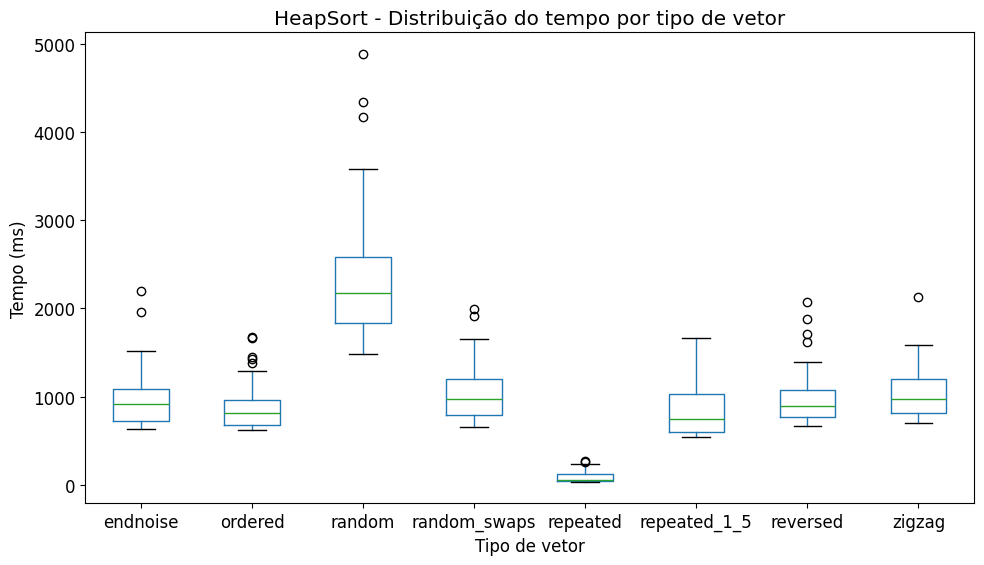

In [5]:
plt.figure(figsize=(8,5))
heap.boxplot(column="time_ms", by="vector_type", grid=False)

plt.title("HeapSort - Distribuição do tempo por tipo de vetor")
plt.suptitle("")
plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")

plt.tight_layout()
plt.show()

### Análise do gráfico:
Verificamos continuação do que vimos somente nas médias, HeapSort muito estável apresentando mediana de 1000 ms para a maioria nos vetores.

Percebemos que o Heapsort é extremamente rápido lidando com vetores repetidos, mas por outro lado vemos que ele não lida muito bem com o random, cuja mediana está acima de 2000 ms.

É támbem possível ver interferência do estresse na estabilidade, ocupação de recursos de hardware começam a introduzir bastante variabilidade

## 5. Gráfico de tempo médio por estresse

<Figure size 1000x500 with 0 Axes>

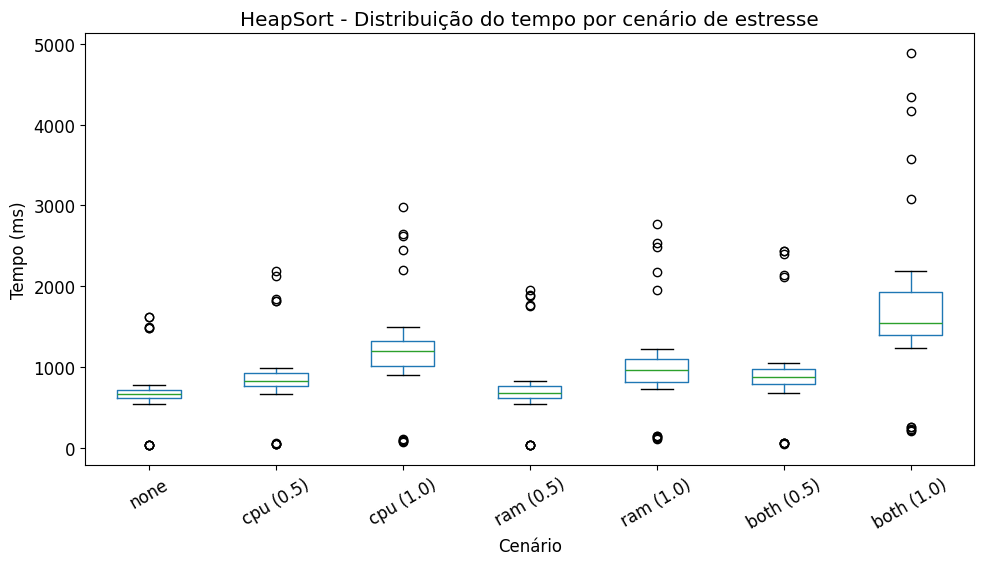

In [28]:
heap["cenario"] = heap.apply(
    lambda x: "none"
    if x["stress"] == "none"
    else f'{x["stress"]} ({x["carga"]})',
    axis=1
)

ordem = [
    "none",
    "cpu (0.5)",
    "cpu (1.0)",
    "ram (0.5)",
    "ram (1.0)",
    "both (0.5)",
    "both (1.0)"
]

heap["cenario"] = pd.Categorical(
    heap["cenario"],
    categories=ordem,
    ordered=True
)

plt.figure(figsize=(10,5))

heap.boxplot(
    column="time_ms",
    by="cenario",
    grid=False
)

plt.title("HeapSort - Distribuição do tempo por cenário de estresse")
plt.suptitle("")
plt.ylabel("Tempo (ms)")
plt.xlabel("Cenário")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Análise do gráfico:
Todos boxplots apresentam estabilidades boas, sendo os 10 outliers sempre as 5 repetições do random (mais longa) e as 5 repetições do repeated (mais curto). Quanto maior o estresse, maior a variabilidade, indicando que a alocação de recursos computacionais introduzem variabilidade

## 6. Gráfico Estresse x Vetor

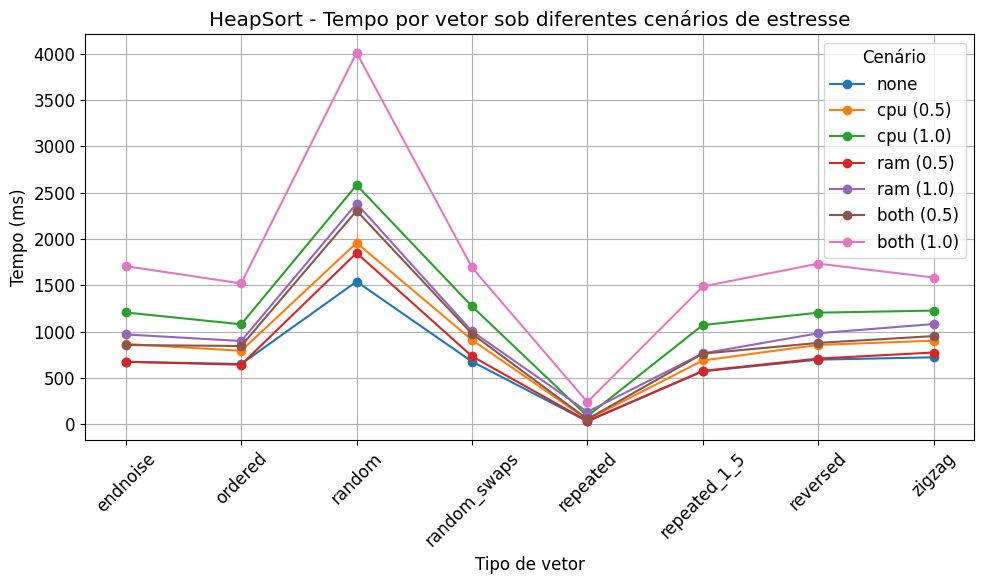

In [10]:
heap["cenario"] = heap.apply(
    lambda x: "none"
    if x["stress"] == "none"
    else f'{x["stress"]} ({x["carga"]})',
    axis=1
)

pivot = (
    heap
    .pivot_table(
        index="vector_type",
        columns="cenario",
        values="time_ms",
        aggfunc="mean"
    )
)

ordem = [
    "none",
    "cpu (0.5)",
    "cpu (1.0)",
    "ram (0.5)",
    "ram (1.0)",
    "both (0.5)",
    "both (1.0)"
]

pivot = pivot[ordem]

pivot.plot(marker="o", figsize=(10,6))

plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")
plt.title("HeapSort - Tempo por vetor sob diferentes cenários de estresse")

plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title="Cenário")

plt.tight_layout()
plt.show()

### Análise do gráfico:
Podemos ver uma ordem geral do estresse no HeapSort:

None é o mais rápido, RAM afeta menos que CPU e both aumenta bastante com os dois aplicados.

Carga é o mais decisivo no tempo.

## 7. Heatmap

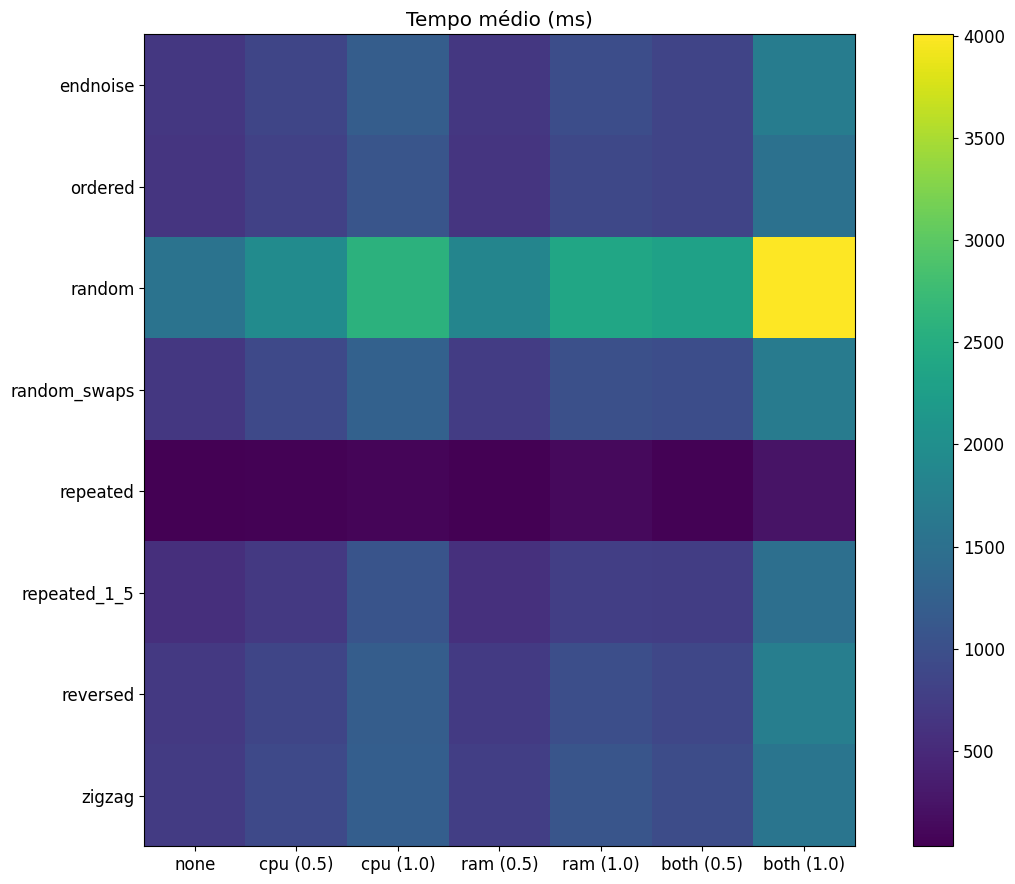

In [13]:
fig, ax = plt.subplots(figsize=(12,9))

im = ax.imshow(pivot.values)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

plt.title("Tempo médio (ms)")

plt.colorbar(im)

plt.tight_layout()
plt.show()

## 8. Memória

<Figure size 800x500 with 0 Axes>

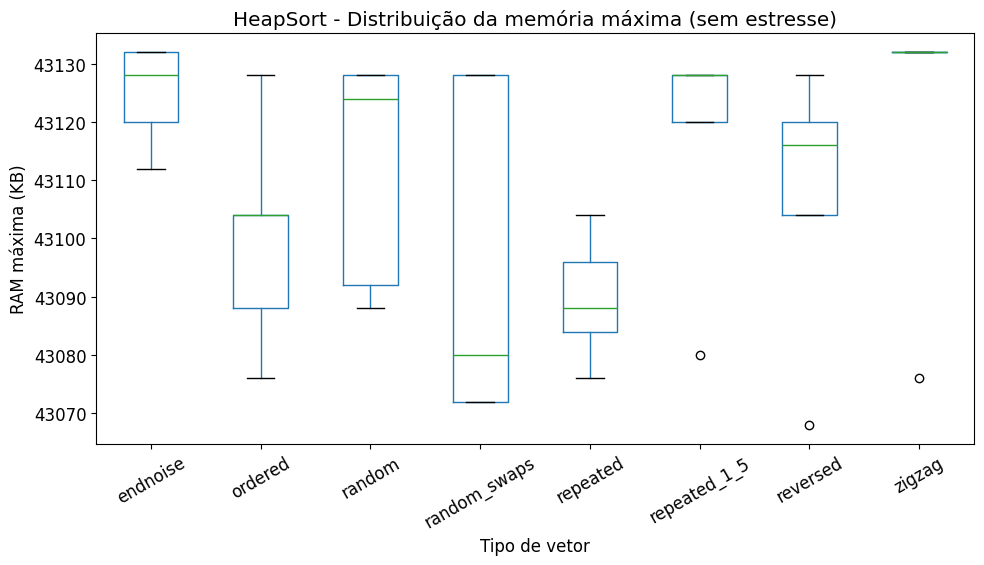

In [16]:
heap_none = heap[heap["stress"] == "none"]

plt.figure(figsize=(8,5))

heap_none.boxplot(
    column="ram_kb_max",
    by="vector_type",
    grid=False
)

plt.title("HeapSort - Distribuição da memória máxima (sem estresse)")
plt.suptitle("")
plt.ylabel("RAM máxima (KB)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Uso de memória é bem constante (já que é definido pelo tamanho do algoritmo), usando no máximo por volta de 43MB de memória.

<Figure size 800x500 with 0 Axes>

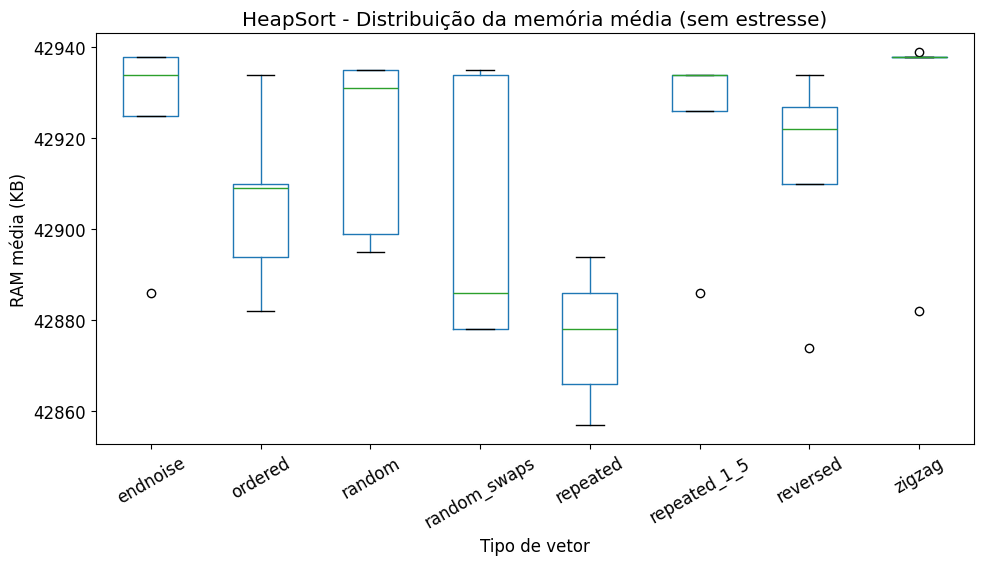

In [18]:
plt.figure(figsize=(8,5))

heap_none.boxplot(
    column="ram_kb_media",
    by="vector_type",
    grid=False
)

plt.title("HeapSort - Distribuição da memória média (sem estresse)")
plt.suptitle("")
plt.ylabel("RAM média (KB)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Uso médio também extremamente constante, ficando na casa de 42,9MB usados em média.

## 9. Energia

<Figure size 800x500 with 0 Axes>

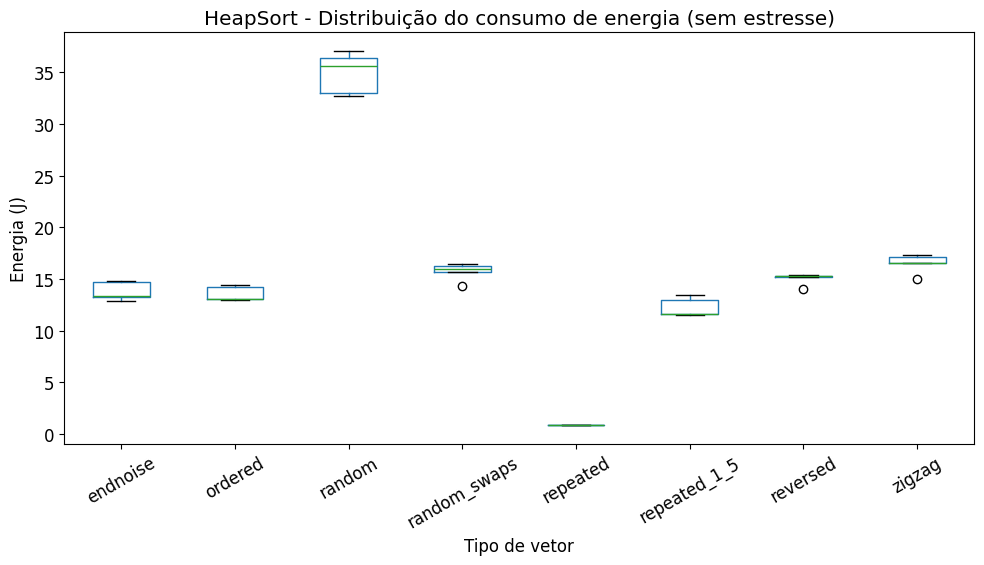

In [23]:
plt.figure(figsize=(8,5))

heap_none.boxplot(
    column="energy_j",
    by="vector_type",
    grid=False
)

plt.title("HeapSort - Distribuição do consumo de energia (sem estresse)")
plt.suptitle("")
plt.ylabel("Energia (J)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Uso de energia segue tempo de execução, como foi visto na etapa 2 do trabalho.

## 10 Correlações

In [27]:
heap_none[[
    "time_ms",
    "ram_kb_max",
    "ram_kb_media",
    "energy_j",
    "swaps",
    "comparisons"
]].corr()

,time_ms,ram_kb_max,ram_kb_media,energy_j,swaps,comparisons
time_ms,1.000000,0.244211,0.386932,0.980466,0.670834,0.674035
ram_kb_max,0.244211,1.000000,0.948520,0.188083,0.286647,0.291277
ram_kb_media,0.386932,0.948520,1.000000,0.339853,0.478484,0.484563
energy_j,0.980466,0.188083,0.339853,1.000000,0.641252,0.644518
swaps,0.670834,0.286647,0.478484,0.641252,1.000000,0.999622
comparisons,0.674035,0.291277,0.484563,0.644518,0.999622,1.000000


Tempo e energia extremamente correlacionados, indicando que energia aumenta quanto mais tempo o sorting leva (esperado). 

Mesma correlação é vista entre uso máximo e médio de energia (também esperado).

Quanto mais swaps, mais comparações e quanto mais swaps e comparações, mais tempo o sorting leva. Correlação entre swaps e comparações e tempo é moderada, indicando ainda outros fatores que influenciam o tempo.

Memória pouco correlacionada com o resto, indicando que o fator principal é o tamanho do vetor inicial

## 11. Conclusões automáticas

In [24]:
print("Maior tempo médio:")

print(
    heap.groupby("vector_type")["time_ms"]
    .mean()
    .idxmax()
)

print("Menor tempo médio:")

print(
    heap.groupby("vector_type")["time_ms"]
    .mean()
    .idxmin()
)

print("Estresse mais custoso:")

print(
    heap.groupby("stress")["time_ms"]
    .mean()
    .idxmax()
)

Maior tempo médio:
random
Menor tempo médio:
repeated
Estresse mais custoso:
both
